In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

In [ ]:
np.random.seed(42)

# Number of samples
n = 200

# Generate random X values
X1 = np.random.uniform(-5, 5, n)
X2 = np.random.uniform(-5, 5, n)

# Quadratic boundary
y = (X2 > X1**2 - 4).astype(int)

# Combine features
X = np.column_stack((X1, X2))

print("Dataset shape:", X.shape)
print("Classes:", np.unique(y))

Dataset shape: (200, 2)
Classes: [0 1]


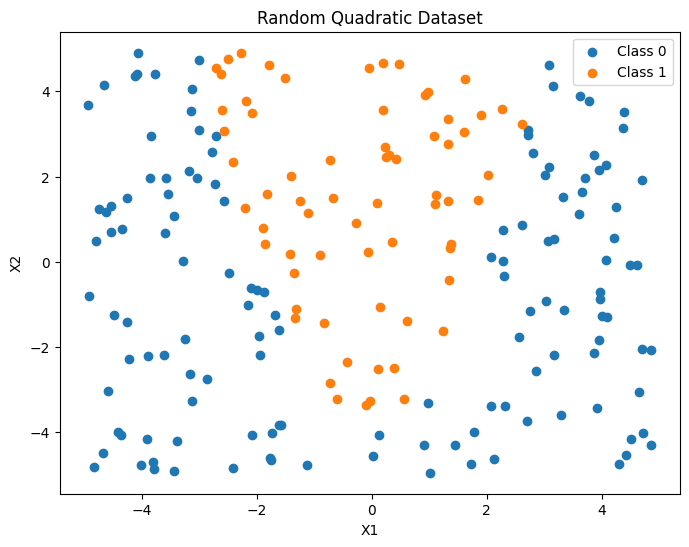

In [ ]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X[y == 0, 0],
    X[y == 0, 1],
    label="Class 0"
)

plt.scatter(
    X[y == 1, 0],
    X[y == 1, 1],
    label="Class 1"
)

plt.xlabel("X1")
plt.ylabel("X2")
plt.title("Random Quadratic Dataset")
plt.legend()
plt.show()

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 160
Testing samples: 40


In [ ]:
svm_model = SVC(
    kernel="rbf",
    C=1.0,
    gamma="scale"
)

svm_model.fit(X_train, y_train)

print("SVM model trained successfully.")

SVM model trained successfully.


In [ ]:
y_pred = svm_model.predict(X_test)

print("Actual values:")
print(y_test)

print("\nPredicted values:")
print(y_pred)

Actual values:
[0 0 0 0 1 1 1 1 0 1 0 0 0 1 0 0 0 0 1 0 0 0 0 1 0 0 0 0 0 1 0 1 0 0 0 0 1
 0 1 1]

Predicted values:
[0 0 0 0 1 1 1 1 0 1 0 1 0 1 0 0 0 0 1 0 0 0 0 1 0 1 0 0 0 1 0 1 1 0 0 0 1
 0 1 1]


In [ ]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Accuracy (%):", accuracy * 100)

Accuracy: 0.925
Accuracy (%): 92.5


In [ ]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       1.00      0.89      0.94        27
           1       0.81      1.00      0.90        13

    accuracy                           0.93        40
   macro avg       0.91      0.94      0.92        40
weighted avg       0.94      0.93      0.93        40



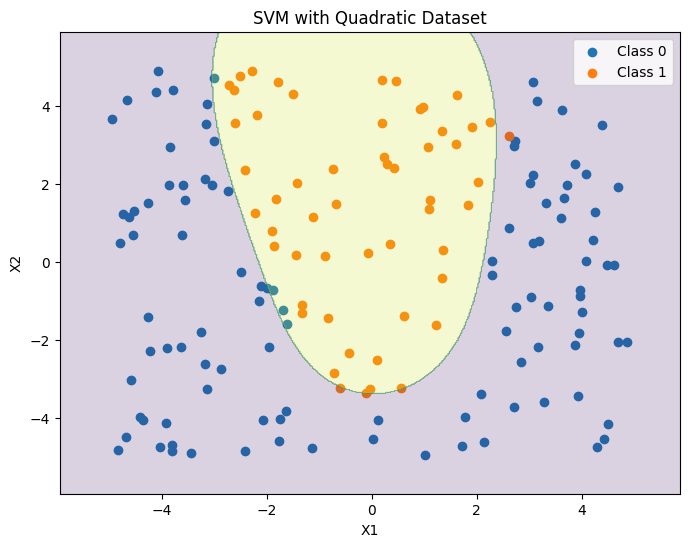

In [ ]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X_train[y_train == 0, 0],
    X_train[y_train == 0, 1],
    label="Class 0"
)

plt.scatter(
    X_train[y_train == 1, 0],
    X_train[y_train == 1, 1],
    label="Class 1"
)

# Create grid
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 500),
    np.linspace(y_min, y_max, 500)
)

grid = np.c_[xx.ravel(), yy.ravel()]

Z = svm_model.predict(grid)

Z = Z.reshape(xx.shape)

plt.contourf(
    xx,
    yy,
    Z,
    alpha=0.2
)

plt.xlabel("X1")
plt.ylabel("X2")
plt.title("SVM with Quadratic Dataset")
plt.legend()
plt.show()

In [ ]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving spambase.data to spambase.data


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [ ]:
columns = [
    "word_freq_make",
    "word_freq_address",
    "word_freq_all",
    "word_freq_3d",
    "word_freq_our",
    "word_freq_over",
    "word_freq_remove",
    "word_freq_internet",
    "word_freq_order",
    "word_freq_mail",
    "word_freq_receive",
    "word_freq_will",
    "word_freq_people",
    "word_freq_report",
    "word_freq_addresses",
    "word_freq_free",
    "word_freq_business",
    "word_freq_email",
    "word_freq_you",
    "word_freq_credit",
    "word_freq_your",
    "word_freq_font",
    "word_freq_000",
    "word_freq_money",
    "word_freq_hp",
    "word_freq_hpl",
    "word_freq_george",
    "word_freq_650",
    "word_freq_lab",
    "word_freq_labs",
    "word_freq_telnet",
    "word_freq_857",
    "word_freq_data",
    "word_freq_415",
    "word_freq_85",
    "word_freq_technology",
    "word_freq_1999",
    "word_freq_parts",
    "word_freq_pm",
    "word_freq_direct",
    "word_freq_cs",
    "word_freq_meeting",
    "word_freq_original",
    "word_freq_project",
    "word_freq_re",
    "word_freq_edu",
    "word_freq_table",
    "word_freq_conference",
    "char_freq_semicolon",
    "char_freq_left_parenthesis",
    "char_freq_left_bracket",
    "char_freq_exclamation",
    "char_freq_dollar",
    "char_freq_hash",
    "capital_run_length_average",
    "capital_run_length_longest",
    "capital_run_length_total",
    "spam"
]

df = pd.read_csv(
    "spambase.data",
    header=None,
    names=columns
)

df.head()

,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,char_freq_semicolon,char_freq_left_parenthesis,char_freq_left_bracket,char_freq_exclamation,char_freq_dollar,char_freq_hash,capital_run_length_average,capital_run_length_longest,capital_run_length_total,spam
0,0.00,0.64,0.64,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.00,0.000,0.0,0.778,0.000,0.000,3.756,61,278,1
1,0.21,0.28,0.50,0.0,0.14,0.28,0.21,0.07,0.00,0.94,...,0.00,0.132,0.0,0.372,0.180,0.048,5.114,101,1028,1
2,0.06,0.00,0.71,0.0,1.23,0.19,0.19,0.12,0.64,0.25,...,0.01,0.143,0.0,0.276,0.184,0.010,9.821,485,2259,1
3,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.137,0.0,0.137,0.000,0.000,3.537,40,191,1
4,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.135,0.0,0.135,0.000,0.000,3.537,40,191,1


In [ ]:
print("Dataset shape:", df.shape)

print("\nNumber of rows:", len(df))
print("Number of columns:", len(df.columns))

print("\nClass distribution:")
print(df["spam"].value_counts())

Dataset shape: (4601, 58)

Number of rows: 4601
Number of columns: 58

Class distribution:
spam
0    2788
1    1813
Name: count, dtype: int64


In [ ]:
X = df[
    [
        "word_freq_free",
        "word_freq_money",
        "word_freq_business",
        "word_freq_you",
        "word_freq_email",
        "capital_run_length_total"
    ]
]

y = df["spam"]

print("Features:")
display(X.head())

print("\nTarget:")
print(y.head())

Features:


,word_freq_free,word_freq_money,word_freq_business,word_freq_you,word_freq_email,capital_run_length_total
0,0.32,0.00,0.00,1.93,1.29,278
1,0.14,0.43,0.07,3.47,0.28,1028
2,0.06,0.06,0.06,1.36,1.03,2259
3,0.31,0.00,0.00,3.18,0.00,191
4,0.31,0.00,0.00,3.18,0.00,191



Target:
0    1
1    1
2    1
3    1
4    1
Name: spam, dtype: int64


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 3680
Testing samples: 921


In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [ ]:
svm_model = SVC(
    kernel="rbf",
    C=1.0,
    gamma="scale"
)

svm_model.fit(
    X_train_scaled,
    y_train
)

print("SVM model trained successfully.")

SVM model trained successfully.


In [ ]:
y_pred = svm_model.predict(X_test_scaled)

print("Predicted values:")
print(y_pred[:20])

print("\nActual values:")
print(y_test.values[:20])

Predicted values:
[0 1 0 1 0 0 0 0 0 1 1 1 0 0 0 0 1 0 0 0]

Actual values:
[1 1 0 1 0 0 0 1 0 1 1 1 0 0 1 0 1 0 0 0]


In [ ]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

print("SVM Accuracy:", accuracy)
print("SVM Accuracy (%):", accuracy * 100)

SVM Accuracy: 0.8436482084690554
SVM Accuracy (%): 84.36482084690554


In [ ]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Not Spam", "Spam"]
    )
)

              precision    recall  f1-score   support

    Not Spam       0.84      0.92      0.88       558
        Spam       0.85      0.73      0.79       363

    accuracy                           0.84       921
   macro avg       0.85      0.82      0.83       921
weighted avg       0.84      0.84      0.84       921



In [ ]:
cm = confusion_matrix(
    y_test,
    y_pred
)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[511  47]
 [ 97 266]]


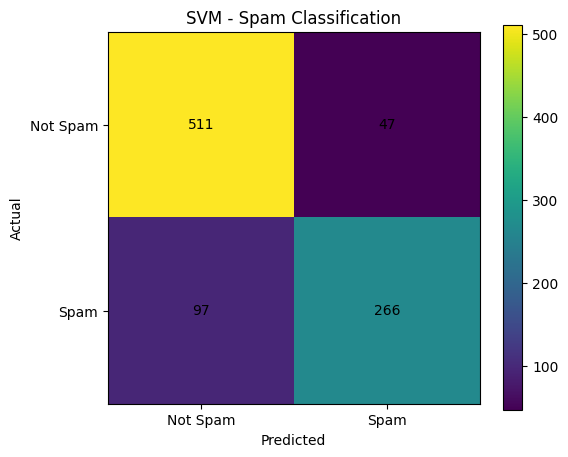

In [ ]:
plt.figure(figsize=(6, 5))

plt.imshow(cm)

plt.title("SVM - Spam Classification")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.xticks(
    [0, 1],
    ["Not Spam", "Spam"]
)

plt.yticks(
    [0, 1],
    ["Not Spam", "Spam"]
)

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.colorbar()
plt.show()

In [ ]:
new_email = pd.DataFrame({
    "word_freq_free": [5.0],
    "word_freq_money": [3.0],
    "word_freq_business": [4.0],
    "word_freq_you": [2.0],
    "word_freq_email": [3.0],
    "capital_run_length_total": [150]
})

new_email_scaled = scaler.transform(new_email)

prediction = svm_model.predict(new_email_scaled)

if prediction[0] == 1:
    print("Prediction: SPAM")
else:
    print("Prediction: NOT SPAM")

Prediction: SPAM


In [ ]:
print("=" * 50)
print("SVM EMAIL SPAM CLASSIFICATION")
print("=" * 50)

print("Dataset:", "UCI Spambase")
print("Total Emails:", len(df))
print("Training Samples:", len(X_train))
print("Testing Samples:", len(X_test))

print("\nFeatures Used:")
for feature in X.columns:
    print("-", feature)

print("\nSVM Kernel: RBF")

print("\nAccuracy:", round(accuracy * 100, 2), "%")

print("\nClassification completed successfully.")

SVM EMAIL SPAM CLASSIFICATION
Dataset: UCI Spambase
Total Emails: 4601
Training Samples: 3680
Testing Samples: 921

Features Used:
- word_freq_free
- word_freq_money
- word_freq_business
- word_freq_you
- word_freq_email
- capital_run_length_total

SVM Kernel: RBF

Accuracy: 84.36 %

Classification completed successfully.
